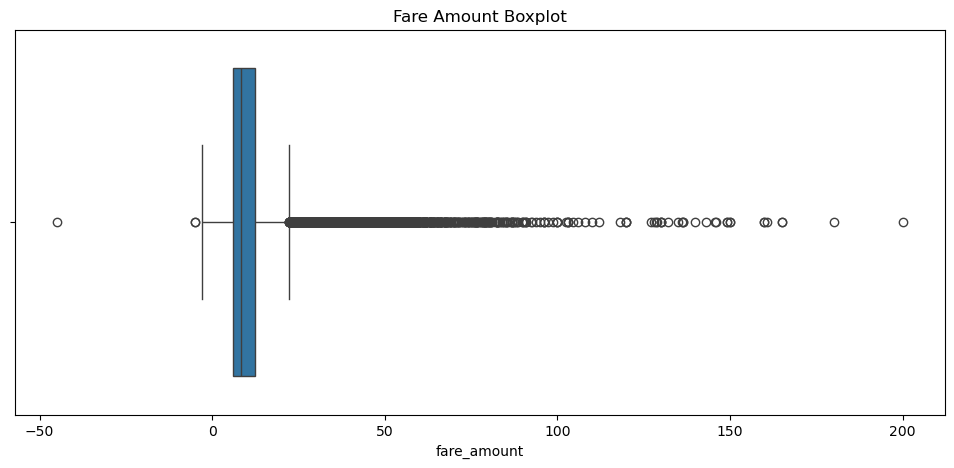

Standard Deviation Method: Detected 2727 anomalies
IQR Method: Detected 8718 anomalies


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (modify the path as needed)
data = pd.read_csv('train.csv', usecols=['fare_amount'], nrows=100000)  # Load only 100k rows

# Basic statistics
mean_fare = data['fare_amount'].mean()
std_fare = data['fare_amount'].std()
q1 = data['fare_amount'].quantile(0.25)
q3 = data['fare_amount'].quantile(0.75)
iqr = q3 - q1

# Define thresholds
std_threshold = 3
lower_std, upper_std = mean_fare - std_threshold * std_fare, mean_fare + std_threshold * std_fare
lower_iqr, upper_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Detect anomalies
anomalies_std = data[(data['fare_amount'] < lower_std) | (data['fare_amount'] > upper_std)]
anomalies_iqr = data[(data['fare_amount'] < lower_iqr) | (data['fare_amount'] > upper_iqr)]

# Visualization
plt.figure(figsize=(12, 5))
sns.boxplot(x=data['fare_amount'])
plt.title('Fare Amount Boxplot')
plt.show()

print(f"Standard Deviation Method: Detected {len(anomalies_std)} anomalies")
print(f"IQR Method: Detected {len(anomalies_iqr)} anomalies")
